In [1]:
#import packages
import pandas as pd
import numpy as np
import geopandas as gpd
import random
from numpy import random

In [ ]:
plot_folder = '/field_data_ucca_08_2025/'
site_name = 'puc'
gui_dir = '/Mac_GUI/projects/puc_test/'


In [3]:
burn_unit = gpd.read_file(gui_dir + 'ff.geojson')

In [ ]:
tree = '04_tree.csv'
# site_name = 'ind'
field_trees = pd.read_csv(plot_folder + tree)  # read the tree data file
plots_df = pd.read_csv(plot_folder + '01_plot_identification.csv')  # read plot identification metadata

plots_df = plots_df[plots_df.site_name == site_name]  # filter to the current site
plots_df = plots_df[plots_df.inventory_pre_post_fire == 'pre']  # keep only pre-fire inventories
field_trees = field_trees.merge(plots_df, on='inventory_id')  # join tree records with plot metadata


In [6]:
field_trees_gpd = gpd.GeoDataFrame(field_trees, 
                                   geometry=gpd.points_from_xy(field_trees.plot_coord_x, field_trees.plot_coord_y),
                                  crs = field_trees.plot_coord_srs[0])


In [7]:
burn_unit = burn_unit.to_crs(field_trees_gpd.crs)
field_trees_gpd = field_trees_gpd.sjoin(burn_unit)

In [8]:
num_trees = field_trees_gpd.shape[0]

In [9]:
num_plots = np.unique(field_trees_gpd.inventory_id).shape[0]

In [ ]:
#calculate the area of the burn unit based on the number of plots and a standard plot size (1/10 acre)
plot_size = (1/10) 
area = num_plots * plot_size #in acres
area = area * 4046.86
nx = np.round(np.sqrt(area))
ny = nx

In [11]:
#randomize the locations 
x_loc = np.random.randint(0, nx, num_trees)
y_loc = np.random.randint(0, ny, num_trees)

In [ ]:
# make the treelist needed for LANL Trees

lanltrees = []
for i in np.arange(num_trees):

    x_coord = x_loc[i]
    y_coord = y_loc[i]
    tree_ht = field_trees_gpd.tree_ht.values[i]
    htc = field_trees_gpd.tree_htlcb.values[i]

    if np.isnan(htc): 
        htc = 1
    
    #these are not measured in the field
    canopy_dia = round(field_trees_gpd.tree_dbh.values[i]/10, 2)
    ht_to_max_canopy = round(((htc + tree_ht) / 2), 2)
    canopy_bulk_density = 3
    canopy_moisture = 1
    canopy_fuel_radius = 5e-04

    
    tree_info = f'1 {x_coord} {y_coord} {tree_ht} {htc} {canopy_dia} {ht_to_max_canopy} {canopy_bulk_density} {canopy_moisture} {canopy_fuel_radius}'
    lanltrees.append(tree_info)

In [14]:
with open(gui_dir + 'lanlTreeList.txt', 'w') as f:
    f.write('\n'.join(lanltrees))

In [15]:
# edit the fuellist and run LANL trees
# ! ./trees.exe

### Look at LANL TREES data

In [16]:
from scipy.io import FortranFile 

def read_dat_file(filename, nz, ny, nx, order= "C"):
    """
    Read in a .dat file as a numpy array.

    Parameters
    ----------
    filename : Path or str
        The path to the .dat file to read.
    nz : int
        The number of cells in the z-direction.
    ny : int
        The number of cells in the y-direction.
    nx : int
        The number of cells in the x-direction.
    order : str, optional
        The order of the array. Default is "C".

    Returns
    -------
    ndarray
        A 3D numpy array representing the data in the .dat file. The array
        has dimensions (nz, ny, nx).
    """
    if isinstance(filename, str):
        filename = (filename)

    with open(filename, "rb") as fin:
        arr = (
            FortranFile(fin)
            .read_reals(dtype="float32")
            .reshape((nz, ny, nx), order=order)
        )

    return arr

In [ ]:
import json

f = open(gui_dir + 'GUIdata.json',)
guidata = json.load(f)

nx = int(guidata['Location']['QF Domain']['Nx'])
ny = int(guidata['Location']['QF Domain']['Ny'])
nz = int(guidata['Location']['QF Domain']['Nz'])


lanl_trees_voxelized = read_dat_file('treesrhof.dat',
                                     nz, ny, nx)

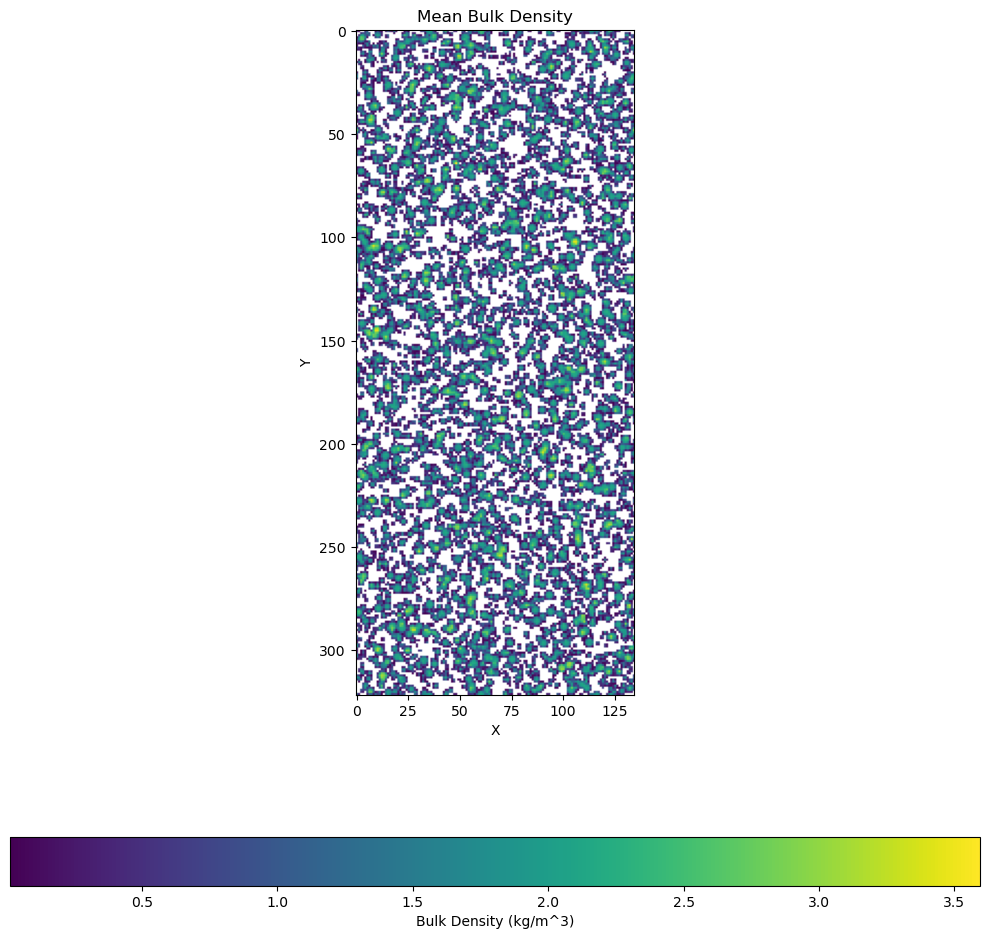

In [22]:
import matplotlib.pyplot as plt
import copy
import numpy as np

data = lanl_trees_voxelized
masked_data = np.ma.masked_where(data <= 0.01, data) # Mask all zeros

# masked_data = np.flipud(masked_data)

current_cmap = copy.copy(plt.cm.viridis)
current_cmap.set_bad(color='white')


fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(np.flipud(masked_data.mean(axis=0)), cmap=current_cmap)
ax.set_title("Mean Bulk Density")
ax.set_xlabel("X")
ax.set_ylabel("Y")
fig.colorbar(im, ax=ax, label="Bulk Density (kg/m^3)", orientation="horizontal")
plt.tight_layout()
plt.show()